In [2]:
import pandas as pd
data=pd.read_csv('/content/encoded_bike_prices.csv')
display(data)

,Unnamed: 0,Brand,Model,Selling_Price,Year,KM_Driven,Ex_Showroom_Price,Seller_Type_Individual,Owner_2nd owner,Owner_3rd owner
0,0,9,183,30000,15.0,8000,30490.0,1.0,0.0,0.0
1,1,2,3,18000,15.0,35000,32000.0,1.0,0.0,0.0
2,2,12,212,20000,9.0,10000,37675.0,1.0,0.0,0.0
3,3,2,16,25000,8.0,43000,42859.0,1.0,0.0,0.0
4,4,2,16,24999,10.0,35000,42859.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
827,1056,7,145,90000,10.0,40000,50267.0,1.0,0.0,0.0
828,1057,3,67,20000,8.0,17000,50267.0,1.0,0.0,0.0
829,1058,2,36,60000,12.0,16000,50267.0,1.0,0.0,0.0
830,1059,3,64,40000,7.0,50000,50267.0,1.0,0.0,0.0


In [6]:
data.describe()

,Brand,Model,Selling_Price,Year,KM_Driven,Ex_Showroom_Price,Seller_Type_Individual,Owner_2nd owner,Owner_3rd owner
count,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000
mean,4.412260,94.631010,43389.411058,11.792067,30950.621394,60269.199519,0.996394,0.116587,0.009615
std,2.913018,57.260901,21234.394255,3.695873,19495.271335,14213.046841,0.059976,0.321120,0.097644
min,0.000000,0.000000,6000.000000,0.000000,380.000000,30490.000000,0.000000,0.000000,0.000000
25%,2.000000,39.000000,26000.000000,9.000000,15000.000000,50267.000000,1.000000,0.000000,0.000000
50%,3.000000,97.000000,40000.000000,12.000000,27892.500000,51994.000000,1.000000,0.000000,0.000000
75%,4.000000,135.000000,55000.000000,15.000000,44000.000000,71074.250000,1.000000,0.000000,0.000000
max,12.000000,212.000000,110000.000000,17.000000,86000.000000,103170.000000,1.000000,1.000000,1.000000


In [5]:
data=data.drop(columns='Unnamed: 0')

In [7]:
lis_norm=['Selling_Price','KM_Driven','Ex_Showroom_Price']

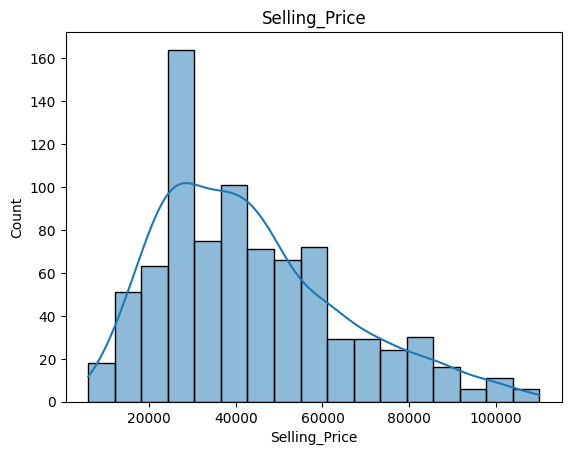

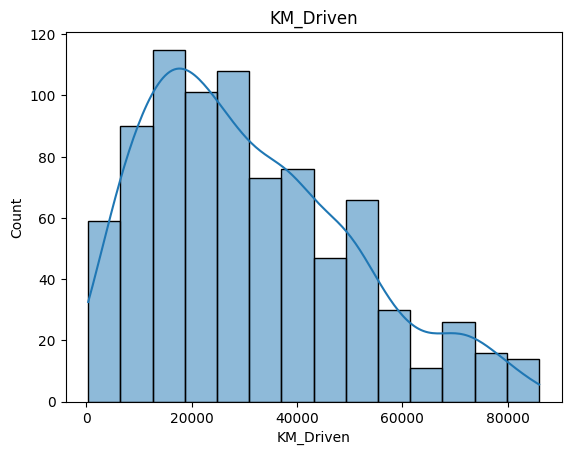

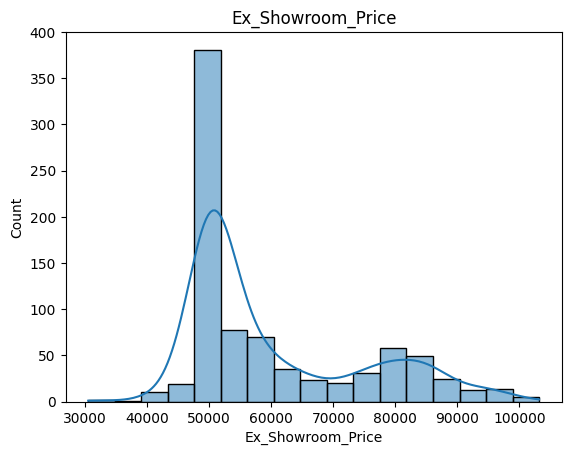

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
for n in lis_norm:
  plt.title(n)
  sns.histplot(data[n],kde=True)
  plt.show()

- visualization (histplot) shows the skewness of columns
    - right skewed,left skewed --> normalization
    - symmetric --> standardizatioin


first-normalization

In [13]:
from sklearn.preprocessing import MinMaxScaler
mi=MinMaxScaler()
data1=data.copy()
data1['Ex_Showroom_Price']=mi.fit_transform(data1[['Ex_Showroom_Price']])
data1['KM_Driven']=mi.fit_transform(data1[['KM_Driven']])
data1['Selling_Price']=mi.fit_transform(data1[['Selling_Price']])

data1

,Brand,Model,Selling_Price,Year,KM_Driven,Ex_Showroom_Price,Seller_Type_Individual,Owner_2nd owner,Owner_3rd owner
0,9,183,0.230769,15.0,0.088998,0.000000,1.0,0.0,0.0
1,2,3,0.115385,15.0,0.404345,0.020776,1.0,0.0,0.0
2,12,212,0.134615,9.0,0.112357,0.098858,1.0,0.0,0.0
3,2,16,0.182692,8.0,0.497781,0.170184,1.0,0.0,0.0
4,2,16,0.182683,10.0,0.404345,0.170184,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
827,7,145,0.807692,10.0,0.462742,0.272111,1.0,0.0,0.0
828,3,67,0.134615,8.0,0.194114,0.272111,1.0,0.0,0.0
829,2,36,0.519231,12.0,0.182434,0.272111,1.0,0.0,0.0
830,3,64,0.326923,7.0,0.579537,0.272111,1.0,0.0,0.0


In [17]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()

data2=data.copy()
data2['Ex_Showroom_Price']=st.fit_transform(data2[['Ex_Showroom_Price']])
data2['KM_Driven']=st.fit_transform(data2[['KM_Driven']])
data2['Selling_Price']=st.fit_transform(data2[['Selling_Price']])
data2

,Brand,Model,Selling_Price,Year,KM_Driven,Ex_Showroom_Price,Seller_Type_Individual,Owner_2nd owner,Owner_3rd owner
0,9,183,-0.630932,15.0,-1.177949,-2.096462,1.0,0.0,0.0
1,2,3,-1.196393,15.0,0.207836,-1.990158,1.0,0.0,0.0
2,12,212,-1.102150,9.0,-1.075298,-1.590636,1.0,0.0,0.0
3,2,16,-0.866541,8.0,0.618438,-1.225682,1.0,0.0,0.0
4,2,16,-0.866588,10.0,0.207836,-1.225682,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
827,7,145,2.196372,10.0,0.464462,-0.704157,1.0,0.0,0.0
828,3,67,-1.102150,8.0,-0.716020,-0.704157,1.0,0.0,0.0
829,2,36,0.782720,12.0,-0.767346,-0.704157,1.0,0.0,0.0
830,3,64,-0.159715,7.0,0.977716,-0.704157,1.0,0.0,0.0


In [18]:
data1.to_csv('normalized_data.csv')